In [2]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import os

from Geometry_methods import set_geom_fuel_shell, make_settings, set_mat, get_material_by_name


In [3]:
# Load materials from XML
#materials = openmc.Materials.from_xml("materials-finish.xml")

#Using fond materials 
#materials = results.export_to_materials(1)
# Collect all nuclides present
nuclides = []

materials = openmc.Materials.from_xml("materials.xml")
mat = get_material_by_name("Fuel_A",materials)


new_geom = True
inner_fuel_r = 48
outer_fuel_r = 50
outer_moderater_r = 87

with_blanket = True
blanket_or = 100

inner_moderator_height = 84

if new_geom:
    geom, _ = set_geom_fuel_shell(inner_fuel_r,outer_fuel_r,outer_moderater_r,with_blanket=with_blanket,
                               blanket_or=blanket_or, inner_moderator_height=inner_moderator_height, fuel_name="Fuel_1")
else:
    geom = openmc.Geometry.from_xml("geometry.xml")


for nuclide, amount,_ in mat.nuclides:
    nuclides.append([nuclide,amount])

print(nuclides)

Fuel_CA_1
Fuel_CA_2
Blanket_CA
Fuel_A
Fuel_B
Fuel_C
Air
h2o
d2o
uo2
[['Li6', 0.026556567149999998], ['Li7', 0.32337843285000006], ['F19', 0.558439], ['Be9', 0.07899999999999999], ['Zr90', 0.005144999999999999], ['Zr91', 0.001122], ['Zr92', 0.001715], ['Zr94', 0.0017380000000000002], ['Zr96', 0.00028000000000000003], ['Th230', 4.000000000000002e-07], ['Th232', 0.001999600000000001], ['U234', 6.485484884668586e-06], ['U235', 0.0005812029061666951], ['U236', 6.430406935507644e-06], ['U238', 3.188120201312881e-05]]


In [22]:
import openmc.data
import re
decay = openmc.data.Decay.from_endf("../endf-b-vii.1/decay/dec-094_Pu_239.endf")

def make_AZ_Str(AZ):
    #Makes sure that number has 3 digits as in endf files and turns the numbers into strings
    if AZ < 10:
        AZstr = f"00{AZ}"
    elif AZ < 100:
        AZstr = f"0{AZ}"
    else:
        AZstr = f"{AZ}"
    return AZstr
def get_decay_data(nuclide_name):
    #Isolating the atomic symbol
    Z, A, m =openmc.data.zam(nuclide_name)
    match = re.match(r"([A-Za-z]+)(\d+)(_)(m\d+)",nuclide_name)
    m1=0
    if match == None:
        match = re.match(r"([A-Za-z]+)",nuclide_name)
        symbol =match.groups()[0]
    else:
        symbol, _,_ ,m1 =match.groups()
    
    Z = make_AZ_Str(Z)
    A = make_AZ_Str(A)

    #Getting decay data from ground state or excited (m1)
    try:
        if m1 != 0:
            dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}{m1}.endf")
        else:
            dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}.endf")
    except Keyerror:
        print("ERROR",Keyerror)
        dec = None
    return dec

def has_alpha_decay(nuclide):
    #Checking if atoms have alpha decay
    nuclide_name=nuclide[0]
    dec = get_decay_data(nuclide_name)
    for mode in dec.modes:
        if mode.modes[0] == "alpha":
            return True
    return False   


#print(has_alpha_decay(nuclides[3]))        
alpha_nuclides = [nuc for nuc in nuclides if has_alpha_decay(nuc)]

print(alpha_nuclides)

[['Th230', 4.000000000000002e-07], ['Th232', 0.001999600000000001], ['U234', 6.485484884668586e-06], ['U235', 0.0005812029061666951], ['U236', 6.430406935507644e-06], ['U238', 3.188120201312881e-05]]


In [25]:
def alpha_decay_values_from_material(material,geom,cell_name,show_discarded=False):
    #Takes a material and returns the amount of alpha decay pr kg
    result = []
    material_mass = 0
    material_cell = geom.get_cells_by_name(cell_name)[0]
    material_cell.fill = material
    try:
        material_cell.volume = material.volume
        #print('material.volume: ',material.volume)
    except Exception as e:
        print(f'Error no material volume defined {e}')
    for nuclide_name, nuclide_amount_percent,_ in material.nuclides:
        #print(nuclide_name, nuclide_amount_percent)
        Z, A, m =openmc.data.zam(nuclide_name)
        #print(f'number of {nuclide_name} atoms {material_cell.atoms[nuclide_name]}')
        nuclide_amount = material_cell.atoms[nuclide_name]
        nuclide_mass = openmc.data.atomic_mass(nuclide_name)
        total_mass = nuclide_mass*nuclide_amount
        #print('nuclide mass', nuclide_mass, 'total mass ',total_mass*1.6605402e-27)
        material_mass += total_mass
        
        dec = get_decay_data(nuclide_name)

        #Seeing if decay constant is possible to return
        try:
            decay_constant = dec.decay_constant.nominal_value #log(2)/half_life
        except ValueError as e:
            if show_discarded:
                print(f"Skipping {dec.nuclide['name']} amount: {nuclide_amount:.3g}: {e}")
                decay_constant = 0
        
        #Finding the spectra and calculating the activity
        if len(dec.spectra)!=0 and has_alpha_decay([nuclide_name]):
            alpha_data=dec.spectra['alpha']
            energies = [float(item['energy'].nominal_value) for item in alpha_data['discrete']] #can be continuous or discrete
            intensities  = [float(item['intensity'].nominal_value) for item in alpha_data['discrete']]

            #This is total activity
            activities = [decay_constant*nuclide_amount*intensity for intensity in intensities] #Calculation of activities
            result.append([nuclide_name,activities,energies])
        else:
            if show_discarded:
                activity=decay_constant*nuclide_amount
                print(dec.nuclide['name'],f"activity: {activity:.3g} has no alpha spectra")

    material_mass = material_mass*1.6605402e-27
    #print(f'total mass of {cell_name} filled with {material.name} is {material_mass:.3g} kg which gives a density of {material_mass*1000/material_cell.volume:.3g} g/cm^3')
    return result, material_mass
fuel = get_material_by_name("Fuel_A",materials)
#print(fuel)
alpha_spectra_data1,total_mass = alpha_decay_values_from_material(fuel,geom,'fuel')


#print([d[0] for d in alpha_spectra_data1])


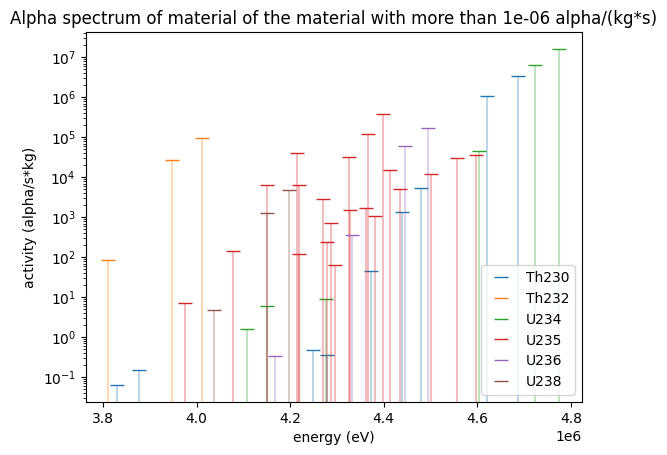

In [26]:
def plot_material_energy_spectra(alpha_spectra_data,total_mass,plot_threshold=1e-5,show_discarded=False):
    fig,ax = plt.subplots()
    
    ax.set_title(f"Alpha spectrum of material of the material with more than {plot_threshold} alpha/(kg*s)")
    ax.semilogy()
    ax.set_xlabel("energy (eV)")
    ax.set_ylabel("activity (alpha/s*kg)")
    for name, activities, energies  in alpha_spectra_data:
        activities_pr_kg = activities/total_mass
        if sum(activities_pr_kg) > plot_threshold:
            line, =ax.plot(energies, activities_pr_kg, "_", label=name,ms=10)
            ax.vlines(energies,[0]*len(energies),activities_pr_kg,line.get_color(),alpha=0.3)
        elif show_discarded:
            print(f'{name} with a total activity of {sum(activities_pr_kg):.2g} alpha/(kg*s) is not plotted')
    ax.legend()

    
plot_material_energy_spectra(alpha_spectra_data1,total_mass,plot_threshold=1e-6)

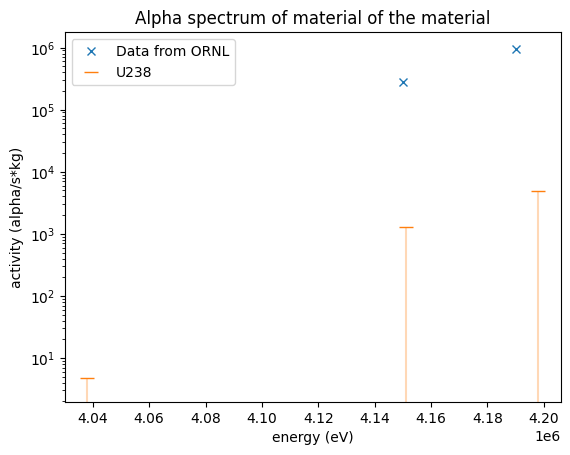

In [15]:
energy_ORNL_dict={
    'U234':[4.77e6,4.72e6],
    'U235':[4.58e6,4.47e6,4.4e6,4.2e6],
    'U236':[4.5e6,4.45e6],
    'U238':[4.19e6,4.15e6]
}
alpha_source_ORNL_dict={
    'U234':[1.64e11,0.64e11],
    'U235':[0.79e7,0.24e7,6.56e7,0.32e7],
    'U236':[1.72e9,0.63e9],
    'U238':[0.95e6,0.28e6]
}


def plot_isotope_in_material(ax,alpha_spectra_data,isotope):
    for name, activities, energies  in alpha_spectra_data:
            activities_pr_kg = activities/total_mass
            if isotope==name:
                line, =ax.plot(energies, activities_pr_kg, "_", label=name,ms=10)
                ax.vlines(energies,[0]*len(energies),activities_pr_kg,line.get_color(),alpha=0.3)

fig,ax = plt.subplots()
    
ax.set_title(f"Alpha spectrum of material of the material")
ax.semilogy()
ax.set_xlabel("energy (eV)")
ax.set_ylabel("activity (alpha/s*kg)")

isotope_name="U238"

ax.plot(energy_ORNL_dict[isotope_name],alpha_source_ORNL_dict[isotope_name],"x",label="Data from ORNL")
plot_isotope_in_material(ax,alpha_spectra_data1,isotope_name)
ax.legend()

In [60]:
def print_deacy_data(nuclide_name):
    dec = get_decay_data(nuclide_name)
    print(dec.modes)
    print('Halflife (s)\t',dec.half_life)
    print(f'Halflife (y)\t{dec.half_life.nominal_value/(3600*24*365.25):.3g}')
    print('Decay_constant\t',dec.decay_constant)
    
    print('\nEnergy \t\t\tIntensity')
    total = 0
    for item in dec.spectra['alpha']['discrete']:
        print(item['energy'],'\t',item['intensity'])
        total+=item['intensity'].nominal_value
    print(f'Total intensity {total:.3g}')
print_deacy_data('U234')



[<DecayMode: (sf), U234 -> U234, (1.70+/-0.10)e-11>, <DecayMode: (alpha), U234 -> Th230, 1.0+/-0>]
Halflife (s)	 (7.747+/-0.019)e+12
Halflife (y)	2.45e+05
Decay_constant	 (8.947+/-0.022)e-14

Energy 			Intensity
(4.1086+/-0.0015)e+06 	 (7.0+/-0.7)e-08
(4.1506+/-0.0015)e+06 	 (2.6+/-0.9)e-07
(4.2761+/-0.0015)e+06 	 (4.0+/-1.0)e-07
(4.6035+/-0.0015)e+06 	 0.00200+/-0.00010
(4.7224+/-0.0014)e+06 	 0.2842+/-0.0009
(4.7746+/-0.0014)e+06 	 0.7138+/-0.0016
Total intensity 1
